# 15 &middot; Pneumatic Actuation: Inflating a Chamber to Steer a Beam

The previous tutorials posed an elastic object by *pulling* on it with handle
springs (tutorial&nbsp;4) and measured the **signed area** enclosed by a closed
mesh outline (tutorial&nbsp;13). This notebook bolts the two ideas together to
build a **soft pneumatic actuator**.

A *pneumatic* actuator is a soft body with a sealed chamber. Pump fluid in, the
chamber wants to enclose more area, and the surrounding material has to deform
to make room &mdash; the deformation *is* the actuation. Robots steer by
arranging chambers so that inflating them bends the structure a chosen way.

We model the chamber with the signed-area outline energy. If $A(x)$ is the area
the chamber outline encloses and $A^\star$ is the area we are commanding it to,

$$
E_{\text{inflate}}(x) \;=\; \tfrac{1}{2}\,k\,\bigl(A(x) - A^\star\bigr)^2 .
$$

Its gradient is $k\,(A-A^\star)\,\nabla A$. The shoelace gradient $\nabla A$ is the
*integrated outward normal* of the chamber wall, so this force pushes every wall
vertex outward &mdash; exactly a **pressure load**, with
$p = k\,(A^\star - A)$ playing the role of internal pressure. We couple it to a
**nonlinear neo-Hookean** elastic energy (full-order FEM, no subspace) and solve
the **quasistatic** equilibrium

$$
x^\star \;=\; \arg\min_x \;\; \underbrace{E_{\text{neo}}(x)}_{\text{elasticity}}
\;+\; \underbrace{\tfrac{1}{2} k\,(A(x)-A^\star)^2}_{\text{pneumatic chamber}}
\;+\; \underbrace{\tfrac{1}{2}\|x_{\text{pin}}-X_{\text{pin}}\|^2_{K}}_{\text{clamp the left wall}}
$$

at every step of a slowly rising target area $A^\star$. Pinning the left edge
turns the beam into a cantilever; an **off-center** chamber inflates
asymmetrically and curls the cantilever up or down.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline

import numpy as np
import scipy.sparse as sps
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# igl's Triangle wrapper meshes a rectangle with an elliptical hole punched out.
import igl
import igl.triangle

import simkit
import simkit.energies as energies
from simkit.solvers import newton_solver
import utils

os.makedirs("media", exist_ok=True)

CHAMBER_C = "#08519c"   # chamber outline
WALL_FACE = "#cfe8df"   # beam fill
WALL_EDGE = "#2a7f62"   # beam mesh edges
PIN_C     = "#3182bd"   # pinned-wall markers

## A beam with a chamber punched out

We triangulate a rectangular beam with a single **elliptical chamber** removed
from its interior. The outer rectangle and the inner ellipse are handed to
Triangle as boundary segments; a *hole point* placed at the ellipse center tells
Triangle to leave that pocket empty.

`chamber_outline` then recovers the chamber wall as a closed edge loop. The mesh
has two boundary loops &mdash; the outer rectangle and the inner ellipse &mdash;
and the chamber is simply the one with the smaller bounding box. That edge loop
is precisely what tutorial&nbsp;13's `outline_areas` consumes, so the chamber's
enclosed area is differentiable in the mesh vertices.

mesh: 1601 vertices, 2916 triangles
chamber rest area |A| = 0.587   (ellipse pi*a*b = 0.587)


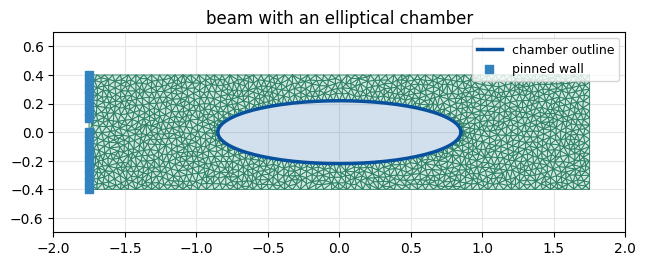

In [2]:
def beam_with_chamber(L=3.5, H=0.8, cx=0.0, cy=0.0, a=0.85, b=0.22,
                      n_chamber=128, max_area=0.0012):
    '''Triangulate a rectangular beam (L x H) with one elliptical chamber
    (semi-axes a, b, centered at (cx, cy)) punched out of it. The chamber must
    fit strictly inside the beam (a thin wall is fine; touching the boundary is
    not) so that the mesh keeps a clean inner loop to inflate.'''
    assert abs(cy) + b < H / 2 - 1e-3 and abs(cx) + a < L / 2, "chamber escapes the beam"
    rect   = np.array([[-L/2, -H/2], [L/2, -H/2], [L/2, H/2], [-L/2, H/2]])
    E_rect = np.array([[0, 1], [1, 2], [2, 3], [3, 0]])

    t   = np.linspace(0, 2 * np.pi, n_chamber, endpoint=False)
    ell = np.stack([cx + a * np.cos(t), cy + b * np.sin(t)], axis=1)
    E_ell = np.stack([np.arange(n_chamber), np.roll(np.arange(n_chamber), -1)], axis=1) + 4

    V = np.vstack([rect, ell])
    E = np.vstack([E_rect, E_ell])
    # q: quality, a<area>: max triangle area, Q: quiet. H marks the hole.
    X, T, _, _, _ = igl.triangle.triangulate(V, E, H=np.array([[cx, cy]]),
                                             flags=f"qa{max_area}Q")
    return X, T


def chamber_outline(X, T):
    '''Closed edge loop of the punched-out chamber (the inner boundary).'''
    loops = igl.boundary_loop_all(T)
    diag  = [np.linalg.norm(X[l].max(0) - X[l].min(0)) for l in loops]
    loop  = loops[int(np.argmin(diag))]          # inner loop = smallest bbox
    return np.stack([loop, np.roll(loop, -1)], axis=1)


# Build one beam with a centered chamber and look at it.
X, T = beam_with_chamber(cx=0.0, cy=0.0)
E_chamber = chamber_outline(X, T)
pin_idx   = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
A_rest    = simkit.outline_areas(X, [E_chamber])[0]
print(f"mesh: {X.shape[0]} vertices, {T.shape[0]} triangles")
print(f"chamber rest area |A| = {abs(A_rest):.3f}   (ellipse pi*a*b = {np.pi*0.85*0.22:.3f})")

fig, ax = plt.subplots(figsize=(8, 2.6))
utils.PolyMeshArtist(ax, X, T, facecolor=WALL_FACE, edgecolor=WALL_EDGE, lw=0.7)
loop = E_chamber[:, 0]
ax.fill(*np.vstack([X[loop], X[loop[0]]]).T, color=CHAMBER_C, alpha=0.18, zorder=3)
ax.plot(*np.vstack([X[loop], X[loop[0]]]).T, "-", color=CHAMBER_C, lw=2.5, zorder=4,
        label="chamber outline")
ax.scatter(X[pin_idx, 0], X[pin_idx, 1], s=40, marker="s", color=PIN_C, zorder=5,
           label="pinned wall")
utils.setup_axes(ax, (-2.0, 2.0), (-0.7, 0.7), title="beam with an elliptical chamber")
ax.legend(loc="upper right", fontsize=9)
plt.show()

## The pneumatic energy

`PneumaticBeam` assembles the three terms of the objective:

* **Neo-Hookean elasticity** &mdash; the full-order, *nonlinear* FEM energy from
  tutorial&nbsp;3/4 (`macklin_mueller_neo_hookean_*_x`). No reduction, no
  subspace: every mesh vertex is a degree of freedom.
* **Pneumatic chamber** &mdash; $\tfrac12 k\,(A(x)-A^\star)^2$. The area, its
  gradient, and its Hessian come straight from `simkit.outline_areas*`. The
  gradient acts only on the chamber-wall vertices, so we scatter the local
  `outline_areas_gradient` (interleaved `[dx0, dy0, ...]`) onto those global
  DOFs.
* **Pin** &mdash; a stiff `dirichlet_penalty` clamping the left wall in place.

For the Hessian we keep the elastic Hessian (PSD-projected) plus the
**Gauss-Newton** part of the chamber term, $k\,\nabla A\,\nabla A^{\top}$, a rank-1
PSD update on the wall DOFs. Dropping the indefinite $k(A-A^\star)\nabla^2 A$ piece
keeps the system positive-definite and Newton robust; it vanishes at convergence
where $A \!\approx\! A^\star$ anyway. The quantity $p = k\,(A^\star - A)$ is the
chamber's internal **pressure**.

In [3]:
class PneumaticBeam:
    '''Quasistatic neo-Hookean beam with one inflatable chamber and a pinned wall.'''

    def __init__(self, X, T, E_chamber, E_young=1e4, nu=0.45,
                 k_inflate=1e5, K_pin=1e9):
        self.X, self.T   = X, T
        self.n, self.dim = X.shape
        self.J   = simkit.deformation_jacobian(X, T)
        self.vol = simkit.volume(X, T)
        mu, lam  = utils.lame_from_E_nu(E_young, nu)
        self.mu  = np.full((len(T), 1), mu)
        self.lam = np.full((len(T), 1), lam)

        # --- pneumatic chamber ---
        self.E_chamber = E_chamber
        self.verts     = np.unique(E_chamber.ravel())     # chamber-wall vertices
        self.A_rest    = simkit.outline_areas(X, [E_chamber])[0]
        self.k_inflate = k_inflate
        self.A_target  = self.A_rest                       # commanded area (per step)
        # global DOFs of the wall, interleaved [x0, y0, x1, y1, ...] to match
        # the ordering of outline_areas_gradient / outline_areas_hessian.
        self.dofs = np.empty(2 * len(self.verts), dtype=int)
        self.dofs[0::2] = 2 * self.verts
        self.dofs[1::2] = 2 * self.verts + 1

        # --- pin the left wall ---
        self.pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
        self.Qp, self.bp = simkit.dirichlet_penalty(self.pin_idx, X[self.pin_idx],
                                                    self.n, K_pin)

    def pressure(self, x):
        A = simkit.outline_areas(x.reshape(-1, self.dim), [self.E_chamber])[0]
        return self.k_inflate * (self.A_target - A)

    def energy(self, x):
        xn = x.reshape(-1, self.dim)
        E_el  = energies.macklin_mueller_neo_hookean_energy_x(xn, self.J, self.mu, self.lam, self.vol)
        A     = simkit.outline_areas(xn, [self.E_chamber])[0]
        E_inf = 0.5 * self.k_inflate * (A - self.A_target) ** 2
        E_pin = 0.5 * (x.T @ (self.Qp @ x))[0, 0] + (self.bp.T @ x)[0, 0]
        return E_el + E_inf + E_pin

    def gradient(self, x):
        xn = x.reshape(-1, self.dim)
        A  = simkit.outline_areas(xn, [self.E_chamber])[0]
        g  = energies.macklin_mueller_neo_hookean_gradient_x(xn, self.J, self.mu, self.lam, self.vol).copy()
        gA = simkit.outline_areas_gradient(xn, [self.E_chamber])[0].ravel()   # local, interleaved
        g[self.dofs, 0] += self.k_inflate * (A - self.A_target) * gA          # pressure load
        g += self.Qp @ x + self.bp
        return g

    def hessian(self, x):
        xn = x.reshape(-1, self.dim)
        He = energies.macklin_mueller_neo_hookean_hessian_x(xn, self.J, self.mu, self.lam, self.vol, psd=True)
        gA = simkit.outline_areas_gradient(xn, [self.E_chamber])[0].ravel()
        # Gauss-Newton chamber term: k * (dA)(dA)^T on the wall DOFs (rank-1, PSD).
        col   = sps.csc_matrix((gA, (self.dofs, np.zeros_like(self.dofs))),
                               shape=(self.n * self.dim, 1))
        H_inf = self.k_inflate * (col @ col.T)
        return (He + H_inf + self.Qp).tocsc()

    def inflate_to(self, A_target, U0, iters=40):
        '''Quasistatic Newton solve at a fixed commanded area.'''
        self.A_target = A_target
        x = newton_solver(U0.reshape(-1, 1), self.energy, self.gradient, self.hessian, max_iter=iters, do_line_search=True)
        return x.reshape(self.n, self.dim)

## Quasistatically inflating the chamber

There is no time, mass, or velocity here &mdash; this is **quasistatic**. We ramp
the commanded chamber area $A^\star$ from its rest value up to `growth` times
larger, and at each step re-solve for static equilibrium with Newton's method,
warm-starting from the previous pose. Each frame is the beam holding still at the
current inflation, so the animation reads as a chamber *slowly* filling up.

area inflated 0.587 -> 2.052  (x3.49)
tip deflection: -0.278
peak chamber pressure |p| = 294.8


saved media/15_pneumatic_inflate.mp4



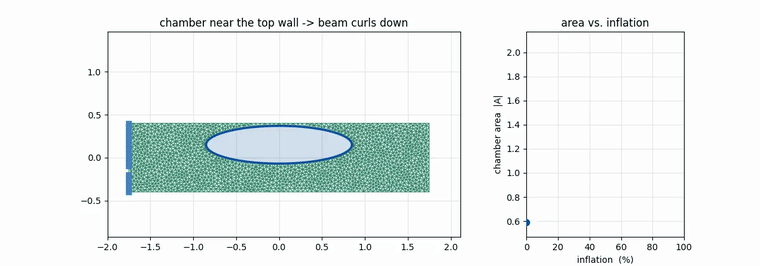

In [4]:
def inflate(beam, growth=3.5, n_steps=36):
    '''Ramp the commanded chamber area to `growth` x rest, solving each step.'''
    U = beam.X.copy()
    states, areas, press = [U.copy()], [beam.A_rest], [0.0]
    for A_t in np.linspace(beam.A_rest, growth * beam.A_rest, n_steps)[1:]:
        U = beam.inflate_to(A_t, U)
        states.append(U.copy())
        areas.append(simkit.outline_areas(U, [beam.E_chamber])[0])
        press.append(beam.pressure(U.reshape(-1, 1)))
    return np.array(states), np.abs(np.array(areas)), np.array(press)


def animate_inflation(beam, states, areas, *, title="", fps=18):
    '''Left: the beam deforming as its chamber inflates. Right: chamber area
    filling in. Returns (fig, anim).'''
    loop  = np.append(beam.E_chamber[:, 0], beam.E_chamber[0, 0])   # closed wall loop
    xs    = np.linspace(0, 100, len(states))                        # inflation %
    xlim, ylim = utils.auto_limits(states, pad=0.25)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2),
                                   gridspec_kw={"width_ratios": [2.4, 1]})
    utils.setup_axes(axL, xlim, ylim, title=title)
    mesh = utils.PolyMeshArtist(axL, states[0], beam.T, facecolor=WALL_FACE,
                                edgecolor=WALL_EDGE, lw=0.7)
    fillholder = {"p": None}
    (wall,) = axL.plot([], [], "-", color=CHAMBER_C, lw=2.5, zorder=4)
    axL.scatter(beam.X[beam.pin_idx, 0], beam.X[beam.pin_idx, 1], s=35, marker="s",
                color=PIN_C, zorder=5)

    trace = utils.TracePlot(axR, xs, {"chamber area": areas}, colors={"chamber area": CHAMBER_C},
                            xlabel="inflation  (%)", ylabel="chamber area  |A|",
                            title="area vs. inflation")

    def update(i):
        mesh.update(states[i])
        wall.set_data(states[i][loop, 0], states[i][loop, 1])
        if fillholder["p"] is not None:
            fillholder["p"].remove()
        fillholder["p"] = axL.fill(states[i][loop, 0], states[i][loop, 1],
                                   color=CHAMBER_C, alpha=0.18, zorder=3)[0]
        trace.update(i)
        return ()

    anim = FuncAnimation(fig, update, frames=len(states), interval=1000 / fps, blit=False)
    return fig, anim


# Off-center (high) chamber: inflating it curls the cantilever downward.
X, T = beam_with_chamber(cy=0.15)
beam = PneumaticBeam(X, T, chamber_outline(X, T))
states, areas, press = inflate(beam)
tip = np.where(X[:, 0] >= X[:, 0].max() - 1e-6)[0]
print(f"area inflated {areas[0]:.3f} -> {areas[-1]:.3f}  (x{areas[-1]/areas[0]:.2f})")
print(f"tip deflection: {states[-1][tip, 1].mean() - X[tip, 1].mean():+.3f}")
print(f"peak chamber pressure |p| = {np.abs(press).max():.1f}")

fig, anim = animate_inflation(beam, states, areas, title="chamber near the top wall -> beam curls down")
out = utils.save_anim(anim, "media/15_pneumatic_inflate.mp4", fps=18)
print("saved", out)
html = utils.show_anim(anim, fps=14, width=760)
plt.close(fig)
html

## Steering: where you put the chamber sets the bend

The chamber position is the actuator's *design knob*. Place it **above** the
beam's neutral axis and the top fibers are forced to stretch more than the bottom
ones as it inflates, so the beam curls **down**. Place it **below** and the beam
curls **up**. A **centered** chamber inflates symmetrically and the beam just
swells in place &mdash; no net bend. We run the same quasistatic inflation for
three chamber heights and play them side by side.

chamber high  ->  curls down      tip dy = -0.278


chamber centered  ->  no bend     tip dy = -0.001


chamber low  ->  curls up         tip dy = +0.279


saved media/15_pneumatic_steering.mp4



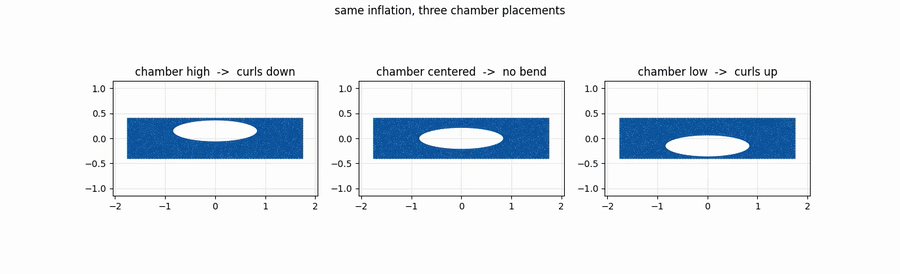

In [5]:
designs = [
    ("chamber high  ->  curls down", +0.15),
    ("chamber centered  ->  no bend",  0.00),
    ("chamber low  ->  curls up",     -0.15),
]

panels, finals = [], []
for label, cy in designs:
    Xd, Td = beam_with_chamber(cy=cy)
    bd = PneumaticBeam(Xd, Td, chamber_outline(Xd, Td))
    sd, ad, _ = inflate(bd)
    panels.append({"states": sd, "T": Td, "title": label})
    finals.append((label, bd, sd))
    tipd = np.where(Xd[:, 0] >= Xd[:, 0].max() - 1e-6)[0]
    print(f"{label:32s}  tip dy = {sd[-1][tipd, 1].mean() - Xd[tipd, 1].mean():+.3f}")

fig, anim = utils.animate_meshes_grid(panels, lims=((-2.05, 2.05), (-1.15, 1.15)),
                                      fps=18, suptitle="same inflation, three chamber placements")
out = utils.save_anim(anim, "media/15_pneumatic_steering.mp4", fps=18)
print("saved", out)
html = utils.show_anim(anim, fps=14, width=900)
plt.close(fig)
html

## A deflection gallery

Sweeping the chamber height through a range of offsets traces out a fan of
deflection angles &mdash; a continuous steering authority from one design
parameter. Below, each fully-inflated final pose is overlaid with its rest shape
(grey) and labeled with the tip angle it reaches.

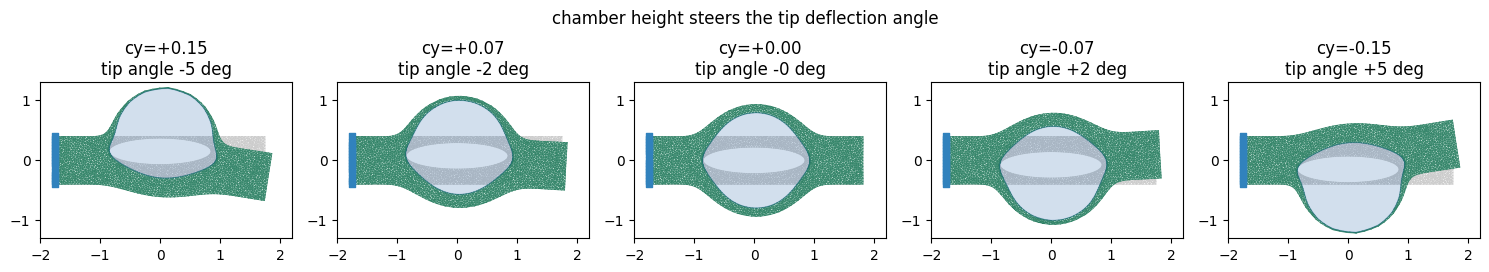

In [6]:
offsets = [+0.15, +0.075, 0.0, -0.075, -0.15]
fig, axes = plt.subplots(1, len(offsets), figsize=(3.0 * len(offsets), 2.8), squeeze=False)
for ax, cy in zip(axes[0], offsets):
    Xg, Tg = beam_with_chamber(cy=cy)
    bg = PneumaticBeam(Xg, Tg, chamber_outline(Xg, Tg))
    sg, _, _ = inflate(bg)
    U = sg[-1]
    loopg = np.append(bg.E_chamber[:, 0], bg.E_chamber[0, 0])
    tipg  = np.where(Xg[:, 0] >= Xg[:, 0].max() - 1e-6)[0]
    dy    = U[tipg, 1].mean() - Xg[tipg, 1].mean()
    ang   = np.degrees(np.arctan2(dy, Xg[:, 0].max() - Xg[:, 0].min()))

    utils.PolyMeshArtist(ax, Xg, Tg, facecolor="none", edgecolor="0.8", lw=0.5)   # rest ghost
    utils.PolyMeshArtist(ax, U, Tg, facecolor=WALL_FACE, edgecolor=WALL_EDGE, lw=0.5)
    ax.fill(U[loopg, 0], U[loopg, 1], color=CHAMBER_C, alpha=0.18, zorder=3)
    ax.scatter(Xg[bg.pin_idx, 0], Xg[bg.pin_idx, 1], s=18, marker="s", color=PIN_C, zorder=5)
    utils.setup_axes(ax, (-2.0, 2.2), (-1.3, 1.3), title=f"cy={cy:+.2f}\ntip angle {ang:+.0f} deg",
                     grid=False)
fig.suptitle("chamber height steers the tip deflection angle")
fig.tight_layout()
fig.savefig("media/15_pneumatic_gallery.png", dpi=130, bbox_inches="tight")
plt.show()

### Takeaways

* A sealed chamber is a **signed-area outline energy**: penalizing
  $\tfrac12 k (A(x)-A^\star)^2$ drives the chamber to a commanded area, and its
  gradient $k(A-A^\star)\nabla A$ is a genuine **pressure load** along the wall
  (the shoelace gradient is the integrated outward normal).
* Coupled to **nonlinear neo-Hookean** full-order FEM and a pinned wall, ramping
  $A^\star$ and re-solving with Newton gives a clean **quasistatic** inflation.
* The chamber's `outline_areas` Hessian is indefinite; the **Gauss-Newton**
  rank-1 part $k\,\nabla A\,\nabla A^\top$ keeps the solve positive-definite and is
  exact at equilibrium.
* **Placement is steering**: an off-center chamber inflates asymmetrically and
  bends the cantilever; the offset sets the deflection angle. Real soft robots
  chain many such chambers to reach, grip, and crawl.